In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Time series libraries
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("seaborn-v0_8")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Walmart.csv to Walmart.csv


In [3]:
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [6]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [7]:
df.dtypes

,0
Store,int64
Date,datetime64[ns]
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


In [8]:
df = df.sort_values("Date")

In [9]:
store1 = df[df['Store'] == 1]
store1.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [10]:
store1.shape

(143, 8)

In [11]:
store1 = store1.set_index("Date")
store1.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106


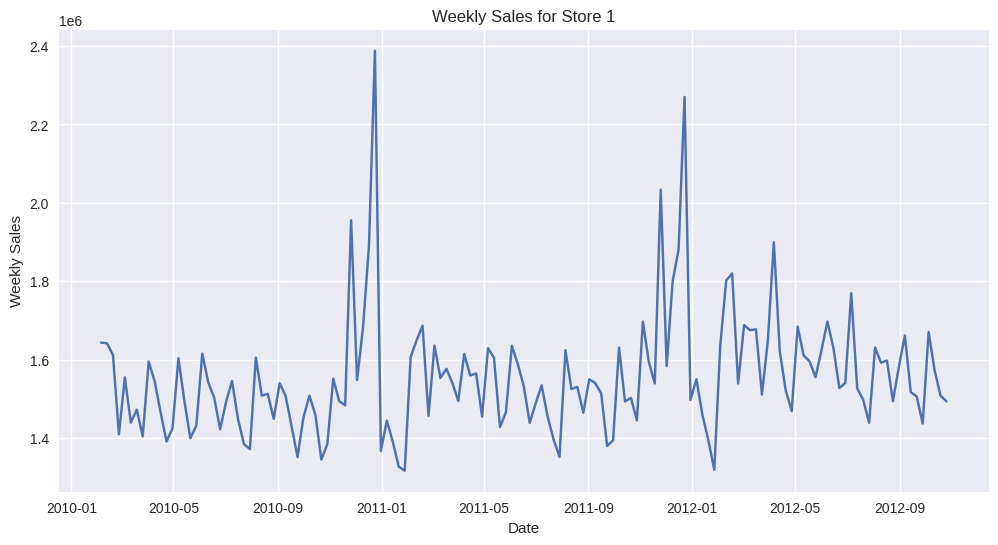

In [12]:
plt.figure(figsize=(12,6))
plt.plot(store1['Weekly_Sales'])
plt.title("Weekly Sales for Store 1")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

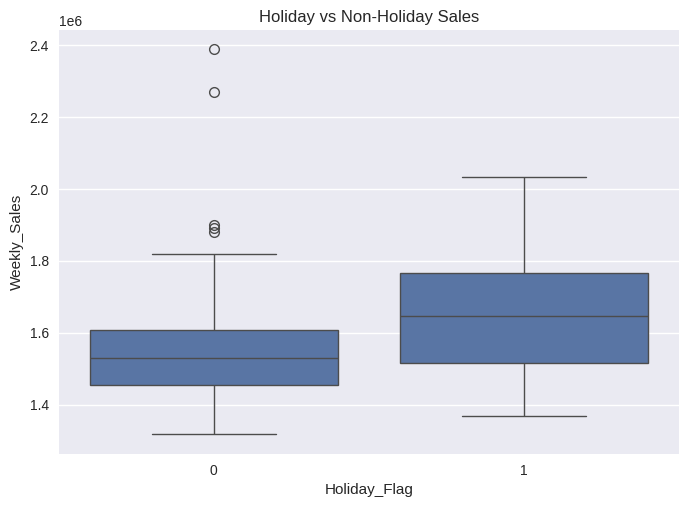

In [13]:
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=store1.reset_index())
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

In [14]:
store1['Weekly_Sales'].describe()

,Weekly_Sales
count,1.430000e+02
mean,1.555264e+06
std,1.559808e+05
min,1.316899e+06
25%,1.458105e+06
50%,1.534850e+06
75%,1.614892e+06
max,2.387950e+06


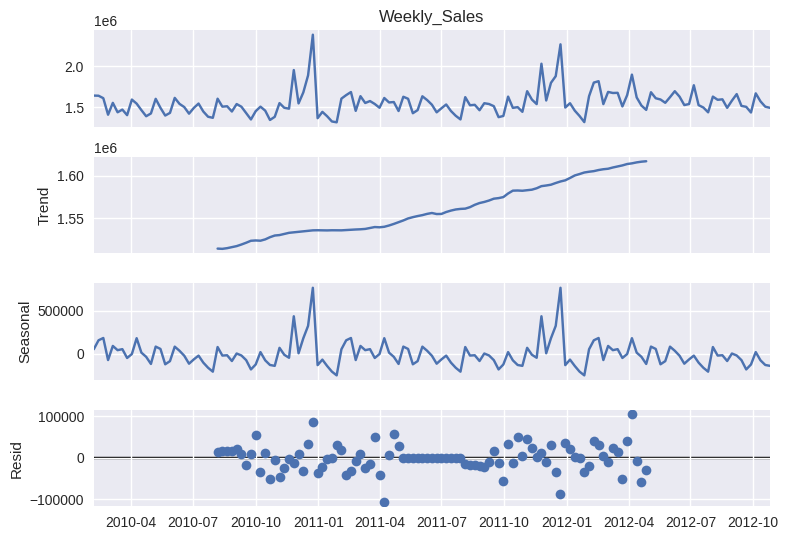

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(store1['Weekly_Sales'], model='additive', period=52)

decomposition.plot()
plt.show()

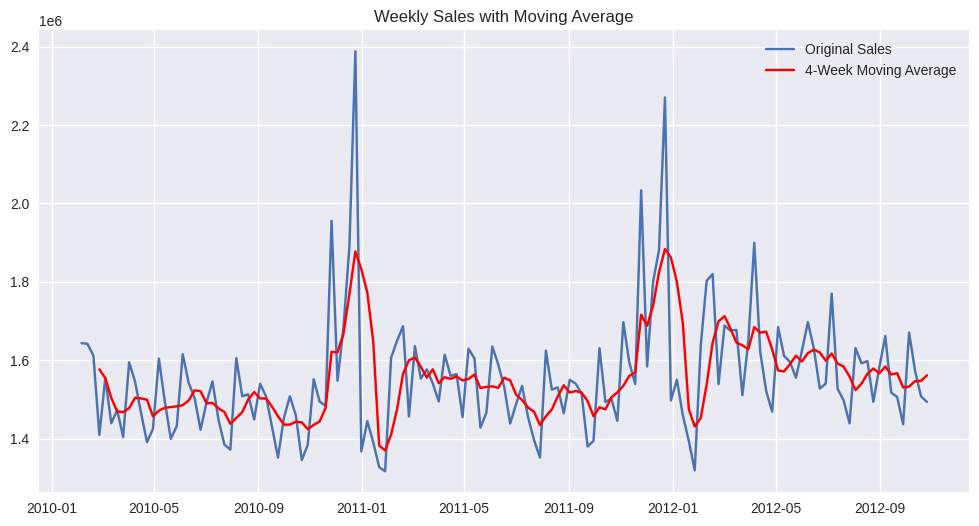

In [16]:
store1['Sales_MA_4'] = store1['Weekly_Sales'].rolling(window=4).mean()

plt.figure(figsize=(12,6))
plt.plot(store1['Weekly_Sales'], label='Original Sales')
plt.plot(store1['Sales_MA_4'], label='4-Week Moving Average', color='red')
plt.legend()
plt.title("Weekly Sales with Moving Average")
plt.show()

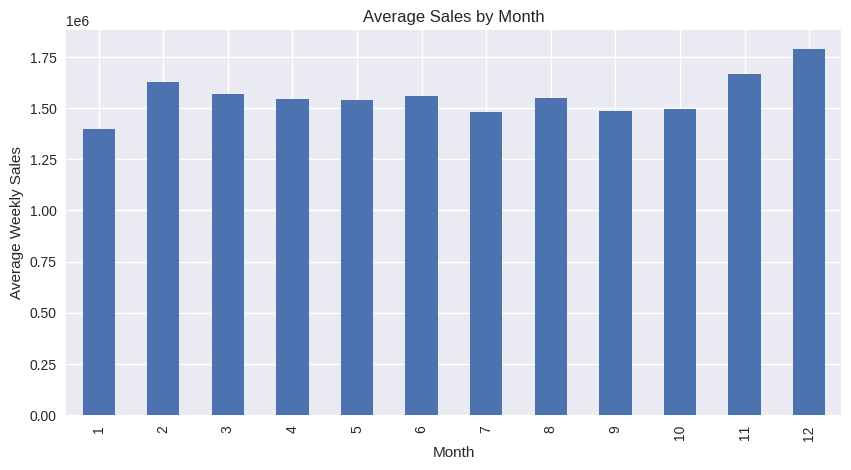

In [17]:
store1['Month'] = store1.index.month

monthly_sales = store1.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.show()

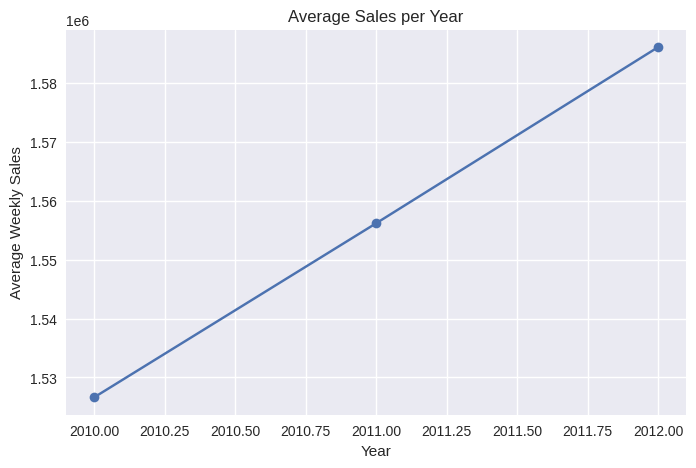

In [18]:
store1['Year'] = store1.index.year

yearly_sales = store1.groupby('Year')['Weekly_Sales'].mean()

yearly_sales.plot(marker='o', figsize=(8,5))
plt.title("Average Sales per Year")
plt.ylabel("Average Weekly Sales")
plt.show()

In [19]:
store1['Year'] = store1.index.year
store1['Month'] = store1.index.month

In [20]:
heatmap_data = store1.pivot_table(
    values='Weekly_Sales',
    index='Year',
    columns='Month',
    aggfunc='mean'
)

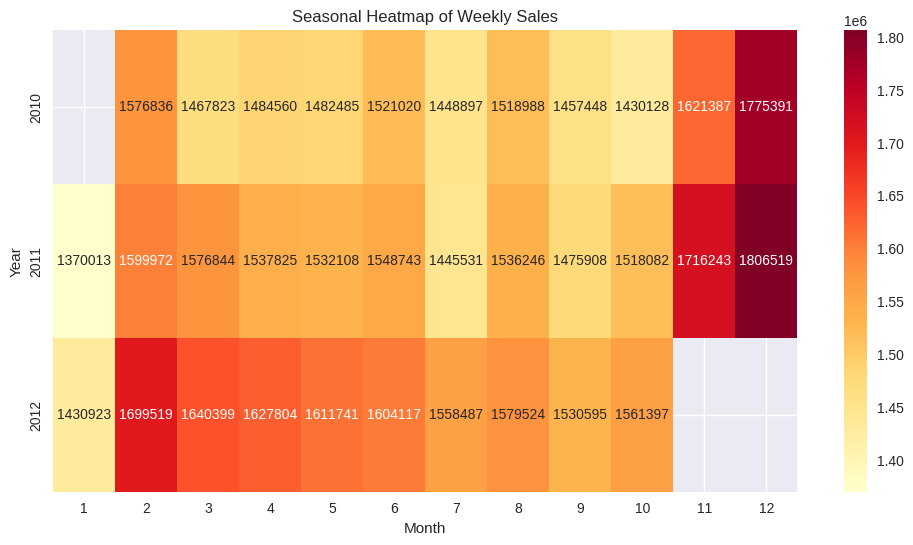

In [21]:
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt=".0f")

plt.title("Seasonal Heatmap of Weekly Sales")
plt.xlabel("Month")
plt.ylabel("Year")

plt.show()

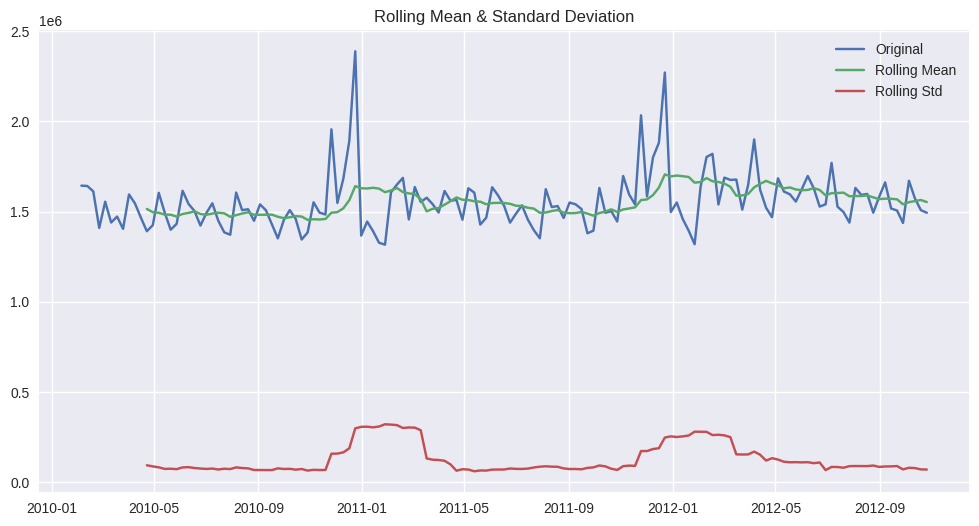

In [22]:
rolling_mean = store1['Weekly_Sales'].rolling(window=12).mean()
rolling_std = store1['Weekly_Sales'].rolling(window=12).std()

plt.figure(figsize=(12,6))
plt.plot(store1['Weekly_Sales'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')

plt.legend()
plt.title("Rolling Mean & Standard Deviation")
plt.show()

In [23]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(store1['Weekly_Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -5.102186145192288
p-value: 1.3877788330759434e-05
Critical Values:
1% : -3.47864788917503
5% : -2.882721765644168
10% : -2.578065326612056


In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1000x500 with 0 Axes>

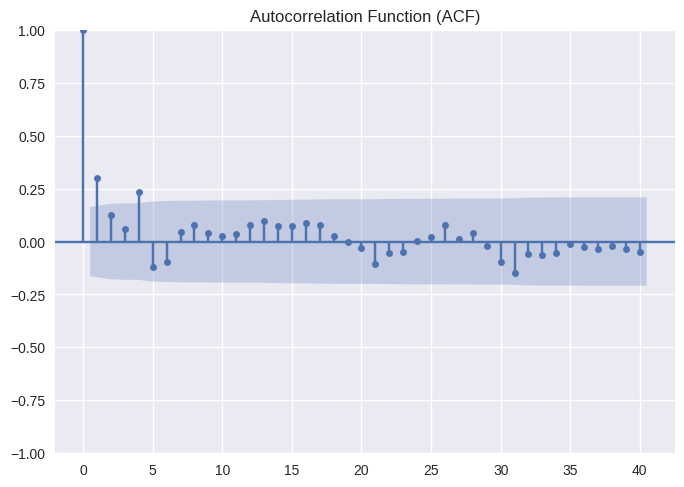

In [25]:
plt.figure(figsize=(10,5))
plot_acf(store1['Weekly_Sales'], lags=40)
plt.title("Autocorrelation Function (ACF)")
plt.show()

<Figure size 1000x500 with 0 Axes>

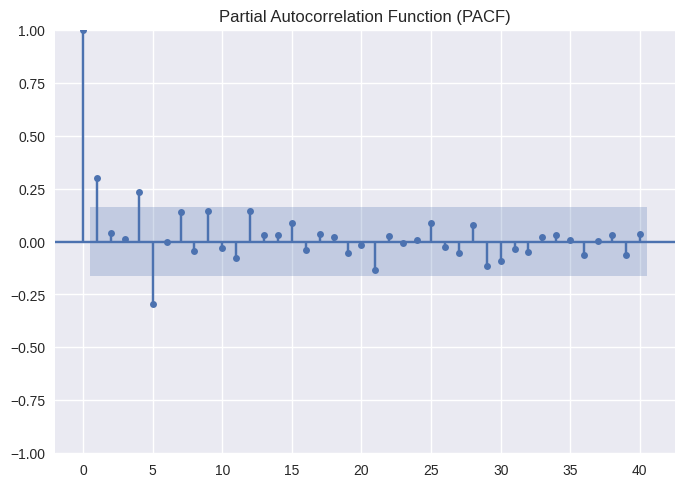

In [26]:
plt.figure(figsize=(10,5))
plot_pacf(store1['Weekly_Sales'], lags=40)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

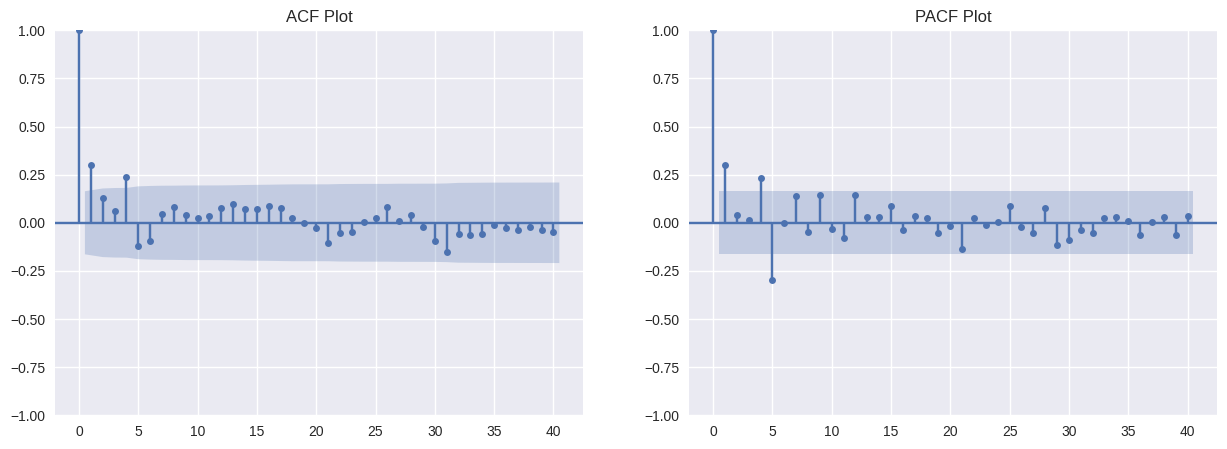

In [27]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

plot_acf(store1['Weekly_Sales'], lags=40, ax=axes[0])
plot_pacf(store1['Weekly_Sales'], lags=40, ax=axes[1])

axes[0].set_title("ACF Plot")
axes[1].set_title("PACF Plot")

plt.show()

In [28]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [30]:
train_size = int(len(store1) * 0.8)

train = store1['Weekly_Sales'][:train_size]
test = store1['Weekly_Sales'][train_size:]

In [31]:
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 114
Test size: 29


In [32]:
model = ARIMA(train, order=(2,0,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(2, 0, 1)   Log Likelihood               -1527.894
Date:                Mon, 16 Mar 2026   AIC                           3065.789
Time:                        12:52:31   BIC                           3079.470
Sample:                    02-05-2010   HQIC                          3071.341
                         - 04-06-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.551e+06   3.07e+04     50.471      0.000    1.49e+06    1.61e+06
ar.L1          0.7080      1.199      0.591      0.555      -1.641       3.057
ar.L2         -0.0631      0.444     -0.142      0.8

In [33]:
forecast = model_fit.forecast(steps=len(test))

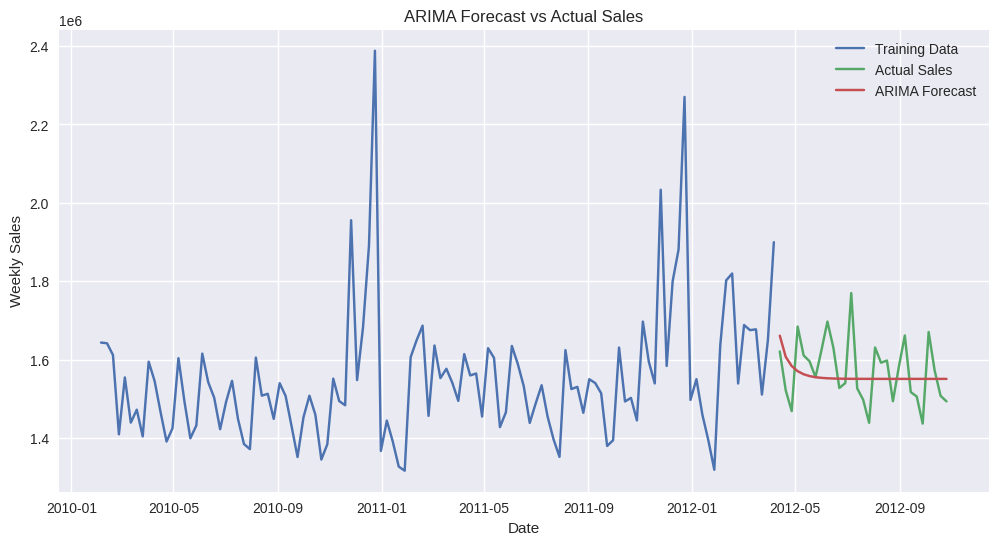

In [34]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Sales")
plt.plot(test.index, forecast, label="ARIMA Forecast")

plt.legend()
plt.title("ARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.show()

In [35]:
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 82669.61926030785
MAE: 68226.75547762321
